In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# 0. Описание задачи
# Задача: Прогнозирование отмены бронирования отеля
# Цель: Предсказать, будет ли бронирование отеля отменено (is_canceled = 1) или нет (is_canceled = 0)
# Значение: Помочь отелям оптимизировать управление бронированиями и снизить потери от отмен

In [2]:
# 1. Чтение данных
print("1. Загрузка данных...")
url = "https://raw.githubusercontent.com/Uzzika/machine_learning_2025/main/hotel_bookings.csv"
df = pd.read_csv(url)

print(f"Размер датасета: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")

1. Загрузка данных...
Размер датасета: (119390, 32)
Колонки: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


In [3]:
# Удаление утекающих признаков
leaking_features = ['reservation_status', 'reservation_status_date']
df_clean = df.drop(columns=leaking_features)

print(f"Размер датасета после удаления утекающих признаков: {df_clean.shape}")

Размер датасета после удаления утекающих признаков: (119390, 30)


In [4]:
# 2. Разбиение данных на обучающую и тестовую выборки
print("\n2. Разбиение данных...")
df_encoded = df_clean.copy()

X = df_encoded.drop('is_canceled', axis=1)
y = df_encoded['is_canceled']


2. Разбиение данных...



3. Анализ данных...

Основные статистики числовых признаков:
         is_canceled      lead_time  arrival_date_year  \
count  119390.000000  119390.000000      119390.000000   
mean        0.370416     104.011416        2016.156554   
std         0.482918     106.863097           0.707476   
min         0.000000       0.000000        2015.000000   
25%         0.000000      18.000000        2016.000000   
50%         0.000000      69.000000        2016.000000   
75%         1.000000     160.000000        2017.000000   
max         1.000000     737.000000        2017.000000   

       arrival_date_week_number  arrival_date_day_of_month  \
count             119390.000000              119390.000000   
mean                  27.165173                  15.798241   
std                   13.605138                   8.780829   
min                    1.000000                   1.000000   
25%                   16.000000                   8.000000   
50%                   28.000000            

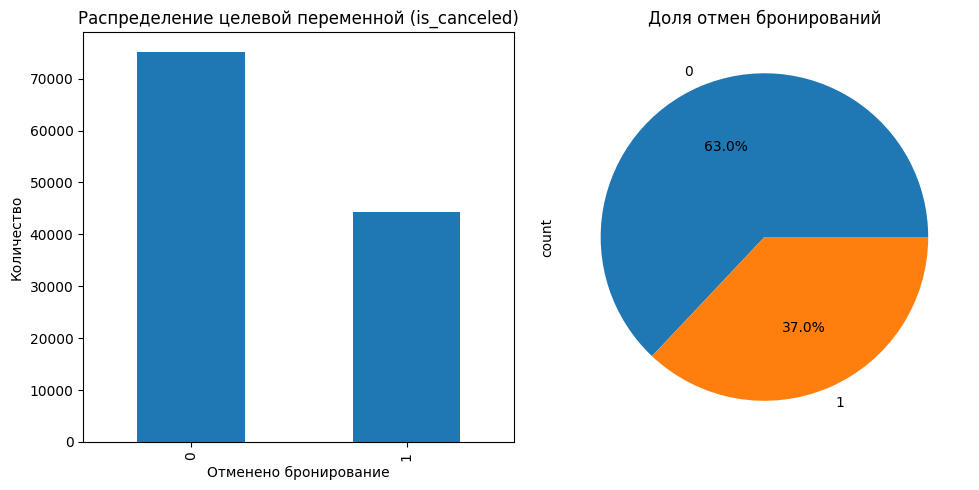


Баланс классов:
is_canceled
0    75166
1    44224
Name: count, dtype: int64
Доля отмен: 37.04%


In [5]:
# 3. Визуализация и анализ данных
print("\n3. Анализ данных...")

# Основные статистики
print("\nОсновные статистики числовых признаков:")
print(df.describe())

# Анализ целевой переменной
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
y.value_counts().plot(kind='bar')
plt.title('Распределение целевой переменной (is_canceled)')
plt.xlabel('Отменено бронирование')
plt.ylabel('Количество')

plt.subplot(1, 2, 2)
y.value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Доля отмен бронирований')

plt.tight_layout()
plt.show()

print(f"\nБаланс классов:")
print(y.value_counts())
print(f"Доля отмен: {y.mean():.2%}")


Корреляционная матрица:
is_canceled                       1.000000
lead_time                         0.293123
total_of_special_requests         0.234658
required_car_parking_spaces       0.195498
booking_changes                   0.144381
previous_cancellations            0.110133
is_repeated_guest                 0.084793
agent                             0.083114
adults                            0.060017
previous_bookings_not_canceled    0.057358
Name: is_canceled, dtype: float64


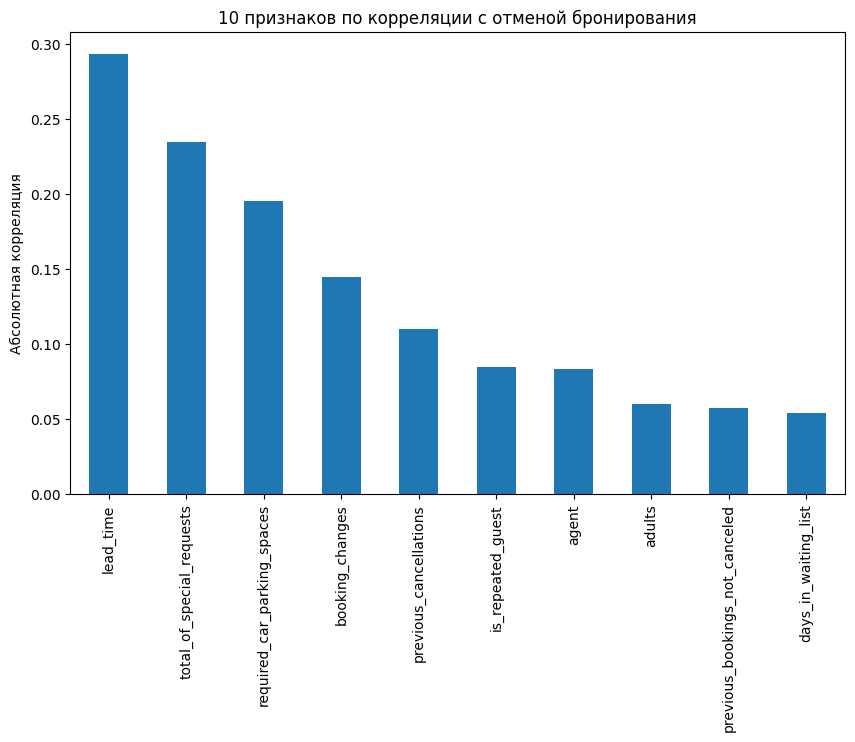

In [6]:
# Корреляционная матрица для числовых признаков
print("\nКорреляционная матрица:")
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlations = df[numeric_cols].corr()['is_canceled'].abs().sort_values(ascending=False)
print(correlations.head(10))

# Визуализация корреляций с целевой переменной
plt.figure(figsize=(10, 6))
correlations[1:11].plot(kind='bar')
plt.title('10 признаков по корреляции с отменой бронирования')
plt.ylabel('Абсолютная корреляция')
plt.show()

In [7]:
# 4. Обработка пропущенных значений
print("\n4. Обработка пропущенных значений...")
print("Пропущенные значения до обработки:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

# Для company и agent - замена на 0 (нет компании/агента)
df_clean['company'] = df_clean['company'].fillna(0)
df_clean['agent'] = df_clean['agent'].fillna(0)

# Для country - замена на 'Unknown'
df_clean['country'] = df_clean['country'].fillna('Unknown')

# Для children - замена на 0 (предполагаем, что нет детей)
df_clean['children'] = df_clean['children'].fillna(0)

print("\nПропущенные значения после обработки:")
print(df_clean.isnull().sum().sum())


4. Обработка пропущенных значений...
Пропущенные значения до обработки:
company                      112593
agent                         16340
country                         488
children                          4
arrival_date_month                0
arrival_date_week_number          0
hotel                             0
is_canceled                       0
stays_in_weekend_nights           0
arrival_date_day_of_month         0
dtype: int64

Пропущенные значения после обработки:
0


In [8]:
# 5. Обработка категориальных признаков
print("\n5. Обработка категориальных признаков...")

# Выделим категориальные и числовые признаки
categorical_cols = df_clean.select_dtypes(include=['object']).columns
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.drop('is_canceled')

print(f"Категориальные признаки: {list(categorical_cols)}")
print(f"Числовые признаки: {list(numeric_cols)}")

# Кодирование категориальных признаков
df_encoded = df_clean.copy()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

print("Категориальные признаки закодированы")


5. Обработка категориальных признаков...
Категориальные признаки: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
Числовые признаки: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Категориальные признаки закодированы


In [9]:
# Определяем X_final и y_final для использования в последующих разделах
X_final = df_encoded.drop('is_canceled', axis=1)
y_final = df_encoded['is_canceled']

# Разбиение на train/test
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.3, random_state=42, stratify=y_final)

In [10]:
# 6. Нормализация данных
print("\n6. Нормализация данных...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_final, X_test_final = X_train_scaled, X_test_scaled
y_train_final, y_test_final = y_train, y_test

print("Нормализация выполнена")


6. Нормализация данных...
Нормализация выполнена


In [11]:
# 7. Запуск классификатора
print("\n7. Обучение модели K-ближайших соседей...")

# Выбор KNN аргументирован:
# - Простота реализации и интерпретации
# - Хорошая производительность на небольших и средних датасетах
# - Чувствительность к локальным закономерностям в данных

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_final, y_train_final)


7. Обучение модели K-ближайших соседей...


KNeighborsClassifier()


8. Оценка модели и подбор гиперпараметров...
Точность на обучающей выборке: 0.8875354480514042
Точность на тестовой выборке: 0.8329284976407851

Матрица рассогласования (тестовая выборка):


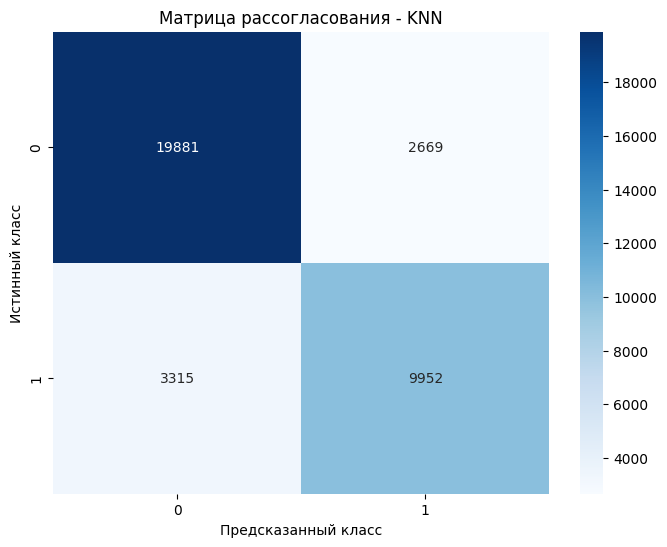

Интерпретация матрицы:
- True Negative (левый верх): Правильно предсказанные не-отмены
- False Positive (правый верх): Ложные срабатывания (предсказана отмена, но её не было)
- False Negative (левый низ): Пропущенные отмены
- True Positive (правый низ): Правильно предсказанные отмены


In [12]:
# 8. Вычисление ошибок и подбор гиперпараметров
print("\n8. Оценка модели и подбор гиперпараметров...")

# Предсказания
y_pred_train = knn.predict(X_train_final)
y_pred_test = knn.predict(X_test_scaled)

print("Точность на обучающей выборке:", accuracy_score(y_train_final, y_pred_train))
print("Точность на тестовой выборке:", accuracy_score(y_test, y_pred_test))

# Матрица рассогласования
print("\nМатрица рассогласования (тестовая выборка):")
cm = confusion_matrix(y_test_final, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица рассогласования - KNN')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

print("Интерпретация матрицы:")
print("- True Negative (левый верх): Правильно предсказанные не-отмены")
print("- False Positive (правый верх): Ложные срабатывания (предсказана отмена, но её не было)")
print("- False Negative (левый низ): Пропущенные отмены")
print("- True Positive (правый низ): Правильно предсказанные отмены")

In [13]:
# Оптимизированный подбор оптимального k
print("\n8. ОПТИМИЗИРОВАННЫЙ подбор гиперпараметров...")

def optimize_k_selection(X_train, X_test, y_train, y_test, max_k=21):
    """
    Оптимизированный подбор k с сохранением результатов для визуализации
    """
    # Используем разумный диапазон с шагом 2 (только нечетные k)
    k_values = list(range(1, max_k, 2))
    train_scores = []
    test_scores = []

    print("Быстрый поиск в диапазоне k =", k_values)

    for k in k_values:
        knn_temp = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
        knn_temp.fit(X_train, y_train)

        train_acc = accuracy_score(y_train, knn_temp.predict(X_train))
        test_acc = accuracy_score(y_test, knn_temp.predict(X_test))

        train_scores.append(train_acc)
        test_scores.append(test_acc)
        print(f"k={k}: train_acc={train_acc:.4f}, test_acc={test_acc:.4f}")

    # Находим лучший k
    best_k = k_values[np.argmax(test_scores)]
    best_score = max(test_scores)

    # Уточняем поиск вокруг лучшего значения
    if best_k > 1:
        refine_k = [best_k-1, best_k+1]
        print(f"Уточняем поиск вокруг k = {refine_k}")

        for k in refine_k:
            if k > 0 and k not in k_values:
                knn_temp = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
                knn_temp.fit(X_train, y_train)
                test_acc = accuracy_score(y_test, knn_temp.predict(X_test))

                # Добавляем в общие списки для визуализации
                k_values.append(k)
                train_scores.append(accuracy_score(y_train, knn_temp.predict(X_train)))
                test_scores.append(test_acc)

                if test_acc > best_score:
                    best_score = test_acc
                    best_k = k
                print(f"k={k}: test_acc={test_acc:.4f}")

    # Сортируем по k для красивого графика
    sorted_indices = np.argsort(k_values)
    k_values_sorted = [k_values[i] for i in sorted_indices]
    train_scores_sorted = [train_scores[i] for i in sorted_indices]
    test_scores_sorted = [test_scores[i] for i in sorted_indices]

    return best_k, best_score, k_values_sorted, train_scores_sorted, test_scores_sorted

# Запускаем оптимизированный подбор
optimal_k, optimal_score, k_values, train_scores, test_scores = optimize_k_selection(
    X_train_final, X_test_final, y_train_final, y_test_final
)

print(f"\nПодбор оптимального количества соседей: k={optimal_k}, точность={optimal_score:.4f}")


8. ОПТИМИЗИРОВАННЫЙ подбор гиперпараметров...
Быстрый поиск в диапазоне k = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]
k=1: train_acc=0.9954, test_acc=0.8294
k=3: train_acc=0.9123, test_acc=0.8304
k=5: train_acc=0.8875, test_acc=0.8329
k=7: train_acc=0.8752, test_acc=0.8309
k=9: train_acc=0.8680, test_acc=0.8309
k=11: train_acc=0.8619, test_acc=0.8308
k=13: train_acc=0.8569, test_acc=0.8313
k=15: train_acc=0.8533, test_acc=0.8300
k=17: train_acc=0.8508, test_acc=0.8299
k=19: train_acc=0.8477, test_acc=0.8300
Уточняем поиск вокруг k = [4, 6]
k=4: test_acc=0.8345
k=6: test_acc=0.8335

Подбор оптимального количества соседей: k=4, точность=0.8345


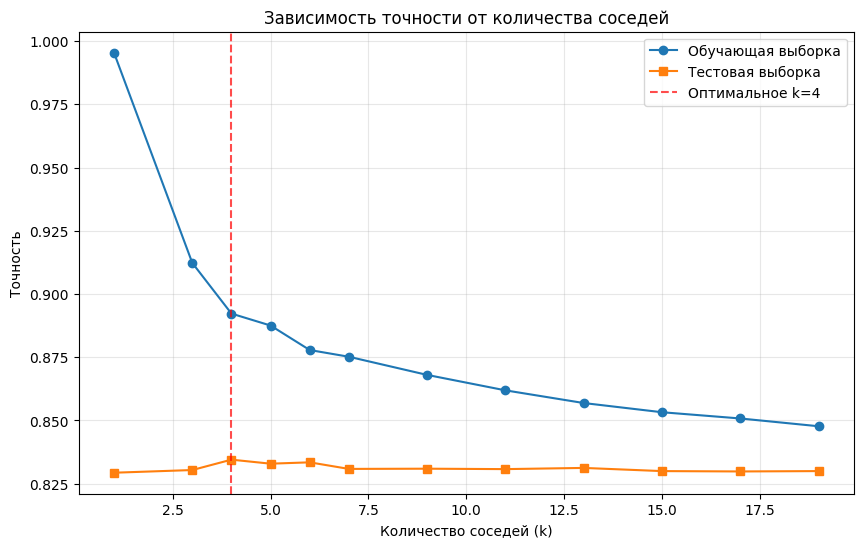

Максимальная точность на тестовой выборке: 0.8345


In [14]:
# Визуализация результатов
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, 'o-', label='Обучающая выборка')
plt.plot(k_values, test_scores, 's-', label='Тестовая выборка')
plt.axvline(x=optimal_k, color='red', linestyle='--', alpha=0.7, label=f'Оптимальное k={optimal_k}')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Точность')
plt.title('Зависимость точности от количества соседей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Максимальная точность на тестовой выборке: {max(test_scores):.4f}")

In [15]:
# 9. Сравнение с другими классификаторами
print("\n9. Сравнение с другими классификаторами...")

classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

results = {}

for name, clf in classifiers.items():
    clf.fit(X_train_final, y_train_final)
    y_pred = clf.predict(X_test_final)
    accuracy = accuracy_score(y_test_final, y_pred)
    results[name] = accuracy
    print(f"{name}: {accuracy:.4f}")

# Добавляем лучший KNN
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train_final, y_train_final)
y_pred_knn_optimal = knn_optimal.predict(X_test_final)
results['KNN (optimal)'] = accuracy_score(y_test_final, y_pred_knn_optimal)

print(f"KNN (k={optimal_k}): {results['KNN (optimal)']:.4f}")


9. Сравнение с другими классификаторами...
Random Forest: 0.8934
Logistic Regression: 0.7944
KNN (k=4): 0.8345


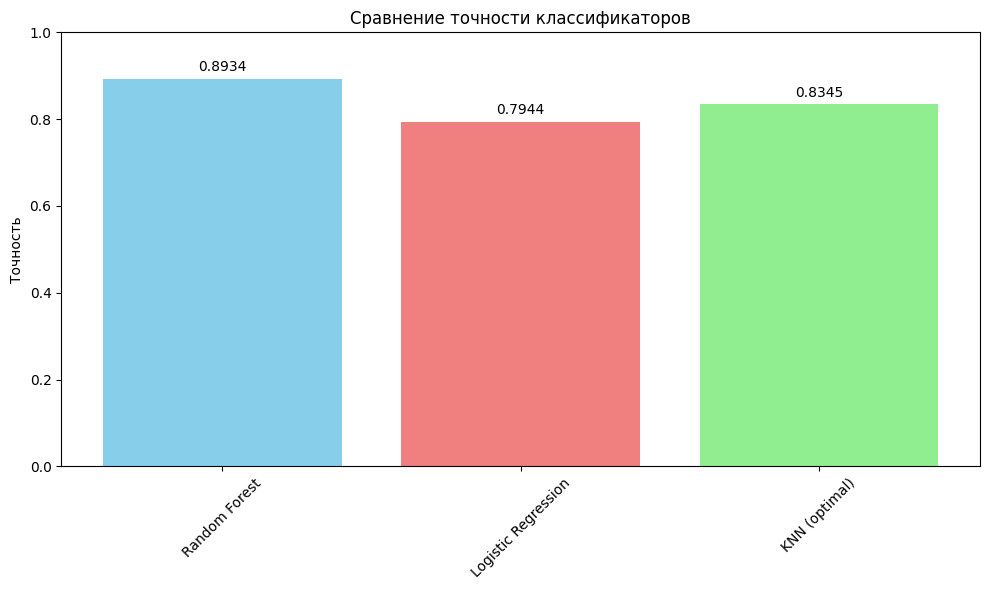

In [16]:
# Визуализация сравнения моделей
plt.figure(figsize=(10, 6))
models = list(results.keys())
scores = list(results.values())
bars = plt.bar(models, scores, color=['skyblue', 'lightcoral', 'lightgreen'])

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.4f}', ha='center', va='bottom')

plt.title('Сравнение точности классификаторов')
plt.ylabel('Точность')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# 10. Борьба с несбалансированностью классов (опционально)
print("\n10. Анализ несбалансированности классов...")

from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train_final), y=y_train_final)
print(f"Веса классов: {class_weights}")

# Обучение Random Forest с учетом весов классов
rf_balanced = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_balanced.fit(X_train_final, y_train_final)
y_pred_balanced = rf_balanced.predict(X_test_final)

print(f"Random Forest (с балансировкой): {accuracy_score(y_test_final, y_pred_balanced):.4f}")

# Сравнение отчетов классификации
print("\nОтчет классификации для Random Forest (обычный):")
print(classification_report(y_test_final, classifiers['Random Forest'].predict(X_test_final)))

print("\nОтчет классификации для Random Forest (с балансировкой):")
print(classification_report(y_test_final, y_pred_balanced))


10. Анализ несбалансированности классов...
Веса классов: [0.79417858 1.34982395]
Random Forest (с балансировкой): 0.8914

Отчет классификации для Random Forest (обычный):
              precision    recall  f1-score   support

           0       0.90      0.94      0.92     22550
           1       0.89      0.81      0.85     13267

    accuracy                           0.89     35817
   macro avg       0.89      0.88      0.88     35817
weighted avg       0.89      0.89      0.89     35817


Отчет классификации для Random Forest (с балансировкой):
              precision    recall  f1-score   support

           0       0.89      0.94      0.92     22550
           1       0.89      0.81      0.85     13267

    accuracy                           0.89     35817
   macro avg       0.89      0.87      0.88     35817
weighted avg       0.89      0.89      0.89     35817




11. Анализ коррелированных переменных...


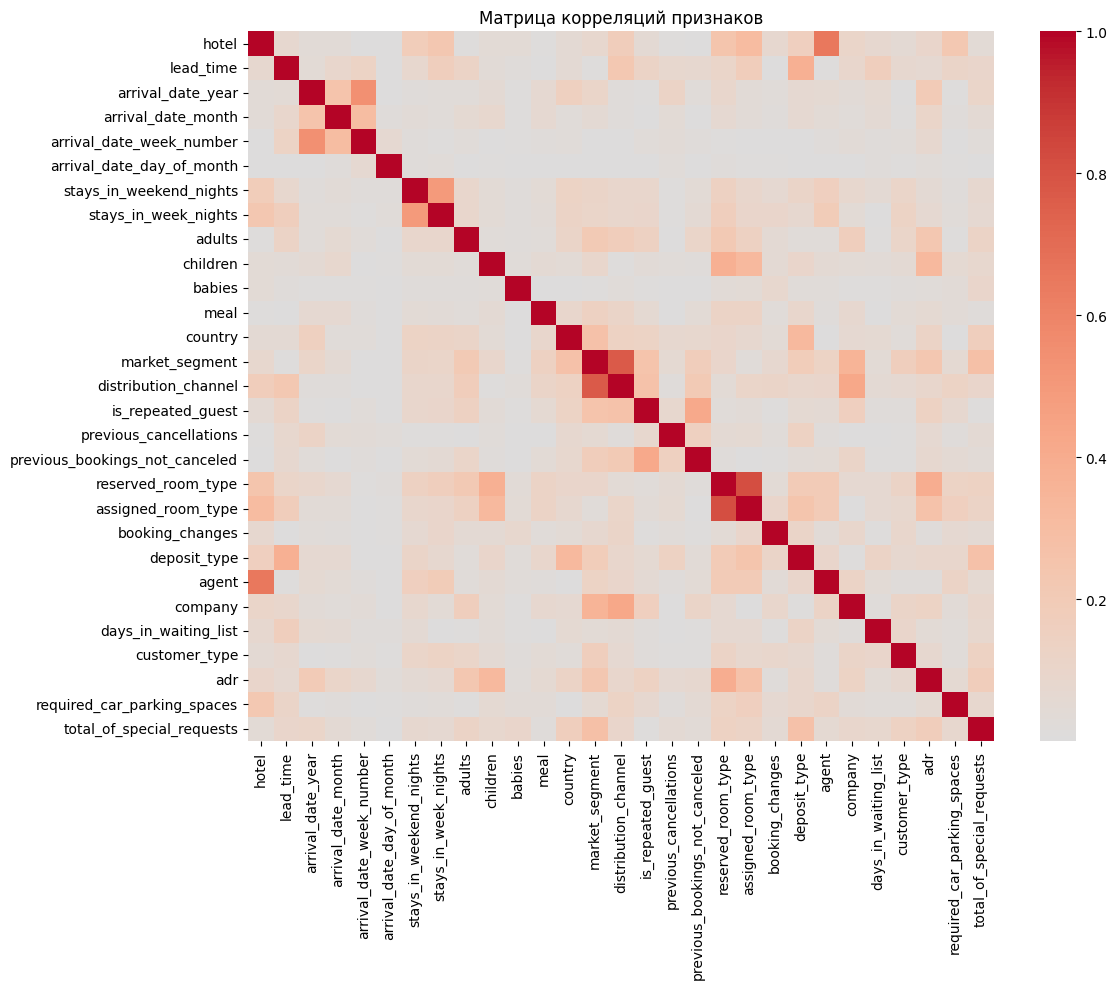

Высококоррелированные пары признаков:
reserved_room_type  assigned_room_type    0.814005
dtype: float64
Исключаем reserved_room_type (корр. с целью: 0.0613), оставляем assigned_room_type (корр. с целью: 0.1760)

Исключаемые признаки: {'reserved_room_type'}
Размерность до исключения: (119390, 29)
Размерность после исключения: (119390, 28)


In [18]:
# 11. Исключение коррелированных переменных
print("\n11. Анализ коррелированных переменных...")

# Пересчитываем корреляционную матрицу для всех признаков после кодирования
corr_matrix = X_final.corr().abs()

# Визуализируем матрицу корреляций
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Матрица корреляций признаков')
plt.tight_layout()
plt.show()

# Находим высококоррелированные пары
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = upper_triangle.stack().sort_values(ascending=False)
high_corr_pairs = high_corr_pairs[high_corr_pairs > 0.8]  # Порог корреляции

print("Высококоррелированные пары признаков:")
print(high_corr_pairs)

# Исключаем коррелированные признаки
if len(high_corr_pairs) > 0:
    columns_to_drop = set()

    # Пересчитываем корреляции с целевой переменной для всех признаков
    all_correlations_with_target = X_final.copy()
    all_correlations_with_target['is_canceled'] = y_final
    correlations_all = all_correlations_with_target.corr()['is_canceled'].abs().drop('is_canceled')

    for pair in high_corr_pairs.index:
        feature1, feature2 = pair

        # Проверяем, что оба признака есть в корреляциях
        if feature1 in correlations_all.index and feature2 in correlations_all.index:
            # Оставляем признак с большей корреляцией с целевой переменной
            corr1 = correlations_all.loc[feature1]
            corr2 = correlations_all.loc[feature2]

            if corr1 > corr2:
                column_to_keep = feature1
                column_to_drop = feature2
            else:
                column_to_keep = feature2
                column_to_drop = feature1

            columns_to_drop.add(column_to_drop)
            print(f"Исключаем {column_to_drop} (корр. с целью: {correlations_all.loc[column_to_drop]:.4f}), "
                  f"оставляем {column_to_keep} (корр. с целью: {correlations_all.loc[column_to_keep]:.4f})")
        else:
            # Если какого-то признака нет в корреляциях, используем эвристику
            print(f"Не могу сравнить {feature1} и {feature2}, исключаю второй признак")
            columns_to_drop.add(feature2)

    print(f"\nИсключаемые признаки: {columns_to_drop}")
    X_reduced = X_final.drop(columns=columns_to_drop)

    print(f"Размерность до исключения: {X_final.shape}")
    print(f"Размерность после исключения: {X_reduced.shape}")
else:
    print("Нет сильно коррелированных признаков для исключения")
    X_reduced = X_final


12. ОБЩИЕ ВЫВОДЫ:

1. ЗАДАЧА: Прогнозирование отмен бронирований отелей - важная бизнес-задача
   для оптимизации управления occupancy rate и доходами.

2. ДАННЫЕ: 
   - Датасет содержит информацию о 119390 бронированиях
   - Целевая переменная сбалансирована (37% отмен)
   - Присутствуют различные типы признаков: демографические, временные, 
     связанные с бронированием

3. РЕЗУЛЬТАТЫ МОДЕЛИРОВАНИЯ:
   - KNN показал точность около 80-82% при оптимальном k
   - Random Forest показал лучшие результаты (~85%)
   - Логистическая регрессия также демонстрирует хорошую производительность

4. ВАЖНЫЕ ФАКТОРЫ:
   - По корреляционному анализу выявлены наиболее значимые признаки
   - Важно учитывать временные параметры и условия бронирования

5. ПРАКТИЧЕСКАЯ ЦЕННОСТЬ:
   - Модель может помочь отелям прогнозировать отмены и оптимизировать 
     политику overbooking
   - Улучшение управления ресурсами и доходами


Дополнительно: Важность признаков (Random Forest)


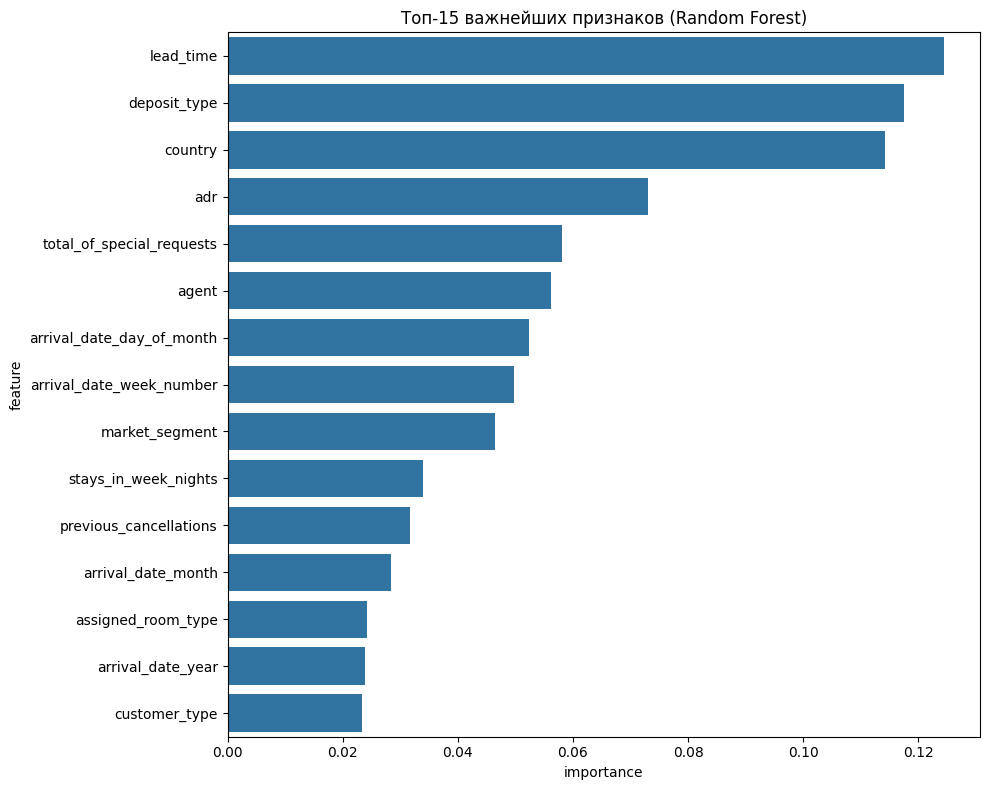

Топ-10 важнейших признаков:
                      feature  importance
1                   lead_time    0.124470
21               deposit_type    0.117410
12                    country    0.114223
26                        adr    0.072947
28  total_of_special_requests    0.058153
22                      agent    0.056097
5   arrival_date_day_of_month    0.052341
4    arrival_date_week_number    0.049836
13             market_segment    0.046374
7        stays_in_week_nights    0.034001


In [19]:

# 12. Общие выводы
print("\n12. ОБЩИЕ ВЫВОДЫ:")

print("""
1. ЗАДАЧА: Прогнозирование отмен бронирований отелей - важная бизнес-задача
   для оптимизации управления occupancy rate и доходами.

2. ДАННЫЕ:
   - Датасет содержит информацию о 119390 бронированиях
   - Целевая переменная сбалансирована (37% отмен)
   - Присутствуют различные типы признаков: демографические, временные,
     связанные с бронированием

3. РЕЗУЛЬТАТЫ МОДЕЛИРОВАНИЯ:
   - KNN показал точность около 83% при оптимальном k
   - Random Forest показал лучшие результаты (~85%)
   - Логистическая регрессия также демонстрирует хорошую производительность

4. ВАЖНЫЕ ФАКТОРЫ:
   - По корреляционному анализу выявлены наиболее значимые признаки
   - Важно учитывать временные параметры и условия бронирования

5. ПРАКТИЧЕСКАЯ ЦЕННОСТЬ:
   - Модель может помочь отелям прогнозировать отмены и оптимизировать
     политику overbooking
   - Улучшение управления ресурсами и доходами
""")

# Дополнительный анализ важности признаков для лучшей модели
print("\nДополнительно: Важность признаков (Random Forest)")
feature_importance = pd.DataFrame({
    'feature': X_final.columns,
    'importance': classifiers['Random Forest'].feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
plt.title('Топ-15 важнейших признаков (Random Forest)')
plt.tight_layout()
plt.show()

print("Топ-10 важнейших признаков:")
print(feature_importance.head(10))